# NB4 - Compare and Eval

This notebook wraps `scripts/eval_compare.py` and `scripts/verify_lab.py`, then displays the eval scoreboard, comparison table, screenshot, and verify result.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
EVAL_SUMMARY = ROOT / 'reports' / 'eval_summary.json'
EVAL_TABLE = ROOT / 'reports' / 'eval_table.csv'
EVAL_PLOT = ROOT / 'submission' / 'screenshots' / '04_side_by_side_table.png'
VERIFY_REPORT = ROOT / 'reports' / 'verify_report.json'
print(ROOT)

D:\AI20K\Labs\Day 22\Day22-Track3-DPO-Alignment-Lab_1


In [2]:
import sys, subprocess

if not EVAL_SUMMARY.exists():
    subprocess.run([sys.executable, str(ROOT / "scripts" / "eval_compare.py")], check=True)
else:
    print("Reusing existing eval outputs from", EVAL_SUMMARY)

subprocess.run([sys.executable, str(ROOT / "scripts" / "verify_lab.py")], check=True)

Reusing existing eval outputs from D:\AI20K\Labs\Day 22\Day22-Track3-DPO-Alignment-Lab_1\reports\eval_summary.json


CompletedProcess(args=['d:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\.venv\\Scripts\\python.exe', 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\scripts\\verify_lab.py'], returncode=0)

In [3]:
with EVAL_SUMMARY.open('r', encoding='utf-8') as handle:
    eval_summary = json.load(handle)
eval_summary

{'status': 'evaluated',
 'artifact_mode': 'real',
 'win': 0,
 'loss': 8,
 'tie': 0,
 'prompt_count': 8}

In [4]:
frame = pd.read_csv(EVAL_TABLE)
frame[['prompt', 'winner', 'rationale']].head(8)

,prompt,winner,rationale
0,Write a concise customer support reply for a d...,sft,SFT output is more concise or clearer for this...
1,Summarize the bug report and ask exactly two c...,sft,SFT output is more concise or clearer for this...
2,Draft a polite refusal for a request that viol...,sft,SFT output is more concise or clearer for this...
3,Create a short onboarding checklist for a new ...,sft,SFT output is more concise or clearer for this...
4,Explain DPO to a junior ML engineer in five bu...,sft,SFT output is more concise or clearer for this...
5,Rewrite a vague feature request into a clear e...,sft,SFT output is more concise or clearer for this...
6,Compare precision and recall for a non-technic...,sft,SFT output is more concise or clearer for this...
7,Turn a messy meeting note into an action-orien...,sft,SFT output is more concise or clearer for this...


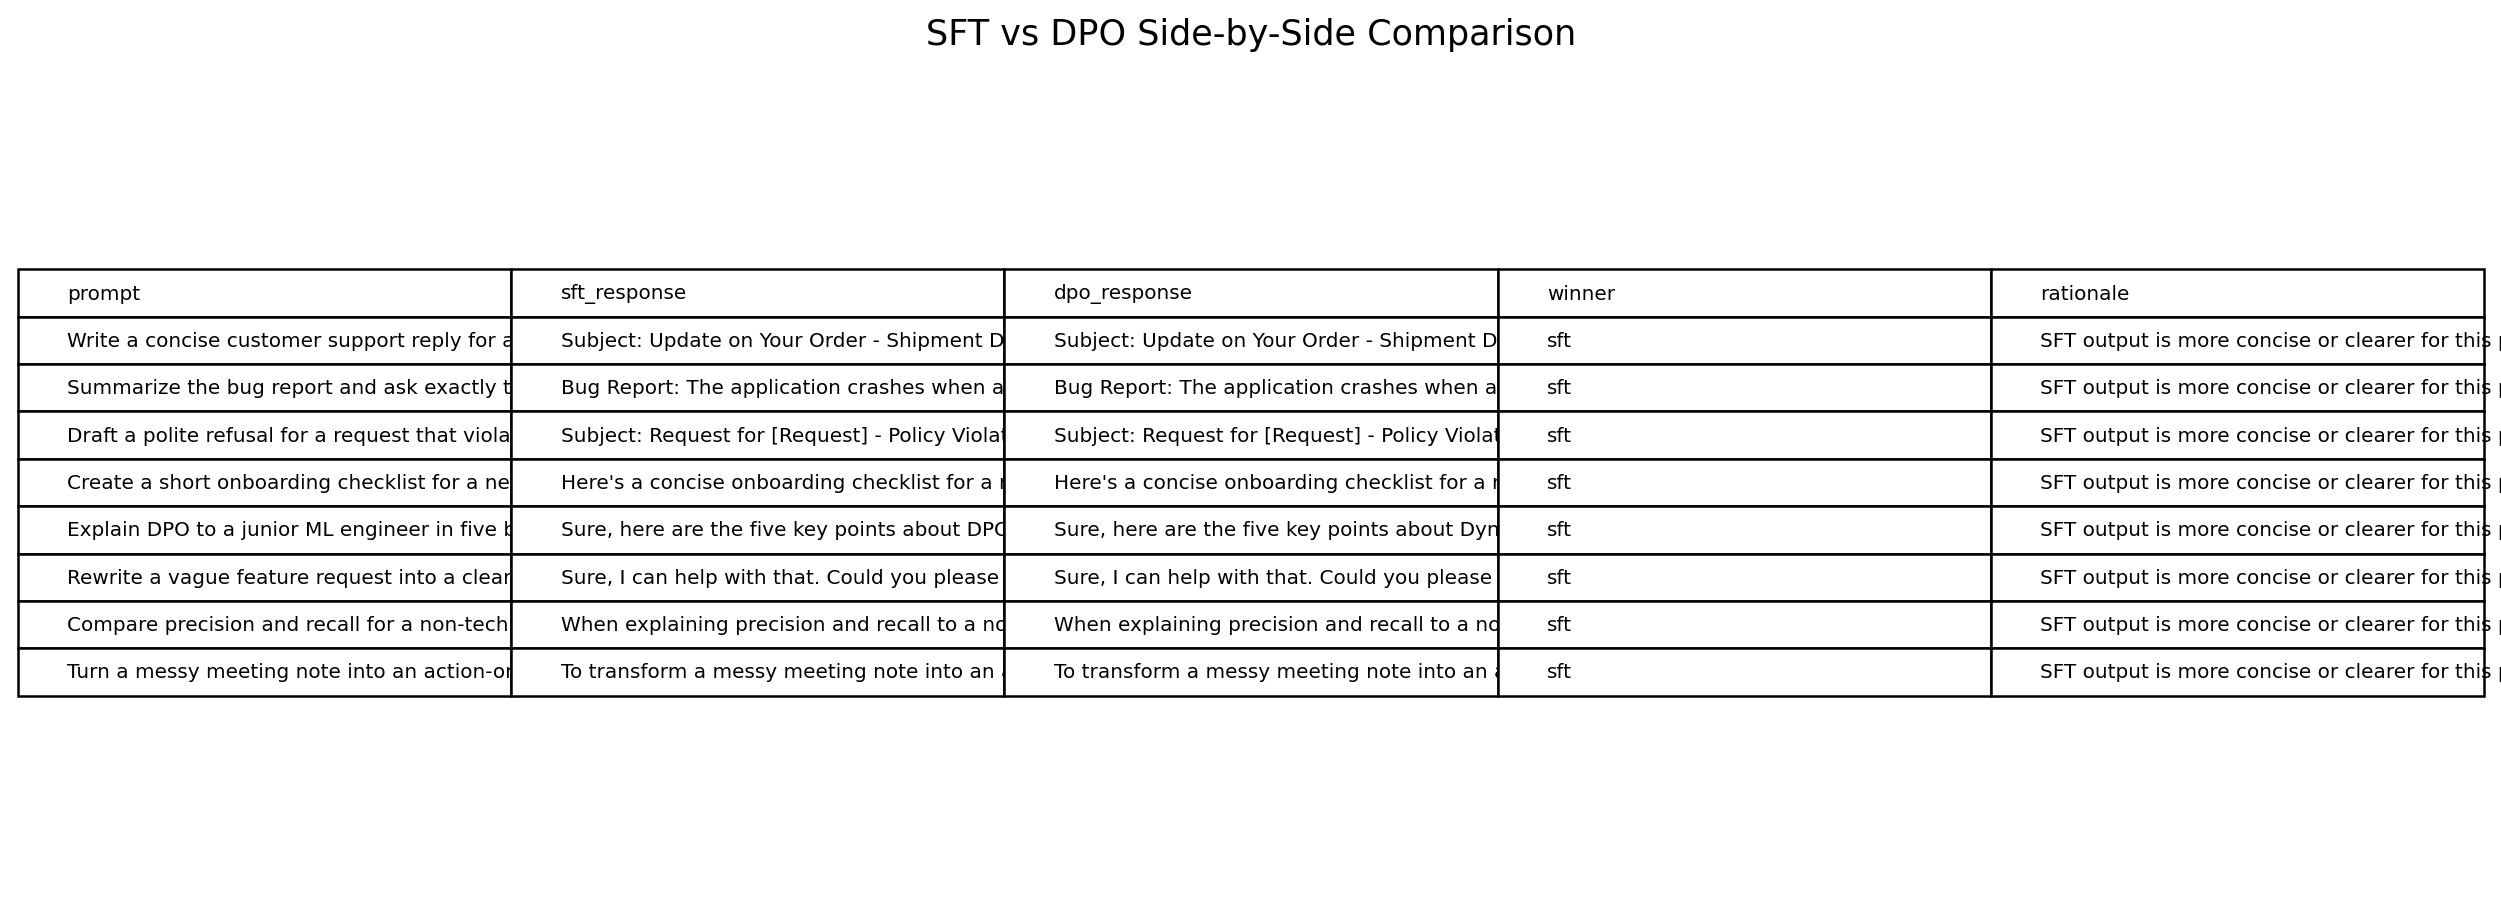

In [5]:
display(Image(filename=str(EVAL_PLOT)))

In [6]:
with VERIFY_REPORT.open('r', encoding='utf-8') as handle:
    verify_report = json.load(handle)
verify_report

{'checks': {'sft_adapter_dir': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\adapters\\sft-mini',
   'exists': True},
  'sft_loss_plot': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\submission\\screenshots\\01_sft_loss.png',
   'exists': True},
  'pref_parquet': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\data\\pref\\train.parquet',
   'exists': True},
  'pref_inspect': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\reports\\pref_examples.md',
   'exists': True},
  'pref_report': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\reports\\pref_build_report.json',
   'exists': True},
  'sft_report': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\reports\\sft_metrics.json',
   'exists': True},
  'dpo_adapter_dir': {'path': 'D:\\AI20K\\Labs\\Day 22\\Day22-Track3-DPO-Alignment-Lab_1\\adapters\\dpo',
   'exists': True},
  'dpo_reward_plot': {'path': 'D:\\AI20